In [1]:
!pip install numpy scipy matplotlib soundfile pydub

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- -----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

from pathlib import Path
from pydub import AudioSegment
from scipy import signal

print("Các thư viện đã được import thành công!")

Các thư viện đã được import thành công!


In [3]:
from pathlib import Path

INPUT_FILE = Path(
    r"C:\XLAT&TN\Lab1\audio\prettyjohn1-beat-523170.mp3"
)

print("File:")
print(INPUT_FILE)

print("\nFile tồn tại:", INPUT_FILE.exists())

File:
C:\XLAT&TN\Lab1\audio\prettyjohn1-beat-523170.mp3

File tồn tại: True


In [4]:
print("=" * 70)
print("THÔNG TIN FILE ÂM THANH GỐC")
print("=" * 70)

audio = AudioSegment.from_mp3(str(INPUT_FILE))

duration = len(audio) / 1000
sample_rate_original = audio.frame_rate
channels_original = audio.channels
sample_width_original = audio.sample_width

print(f"File             : {INPUT_FILE.name}")
print(f"File size        : {INPUT_FILE.stat().st_size / 1024**2:.2f} MB")
print(f"Duration         : {duration:.2f} seconds")
print(f"Sampling rate    : {sample_rate_original} Hz")
print(f"Channels         : {channels_original}")
print(f"Bit depth        : {sample_width_original * 8} bit")

THÔNG TIN FILE ÂM THANH GỐC
File             : prettyjohn1-beat-523170.mp3
File size        : 2.13 MB
Duration         : 69.93 seconds
Sampling rate    : 44100 Hz
Channels         : 2
Bit depth        : 16 bit


In [5]:
print("=" * 70)
print("CHUYỂN ĐỔI FILE")
print("=" * 70)

# Stereo -> Mono
audio_mono = audio.set_channels(1)

# Đưa sampling rate về 44.1 kHz
audio_mono = audio_mono.set_frame_rate(44100)

# 16-bit PCM
audio_mono = audio_mono.set_sample_width(2)

# File WAV đầu ra
wav_file = OUTPUT_DIR / "input_mono_44k1_16bit.wav"

audio_mono.export(
    wav_file,
    format="wav"
)

print("Đã tạo file:")
print(wav_file)

print()
print("Thông số:")
print(f"Sampling rate : {audio_mono.frame_rate} Hz")
print(f"Channels      : {audio_mono.channels}")
print(f"Bit depth     : {audio_mono.sample_width * 8} bit")
print(f"Duration      : {len(audio_mono)/1000:.2f} seconds")

CHUYỂN ĐỔI FILE
Đã tạo file:
lab1_results\input_mono_44k1_16bit.wav

Thông số:
Sampling rate : 44100 Hz
Channels      : 1
Bit depth     : 16 bit
Duration      : 69.93 seconds


In [6]:
x, Fs = sf.read(
    str(wav_file),
    always_2d=False
)

# Nếu file vẫn là stereo thì chuyển sang mono
if x.ndim > 1:
    x = np.mean(x, axis=1)

# Chuyển sang float64 để tính toán
x = x.astype(np.float64)

# Số mẫu
N = len(x)

# Thời lượng
duration = N / Fs

# Trục thời gian
time = np.arange(N) / Fs

print("=" * 70)
print("THÔNG TIN TÍN HIỆU SAU KHI ĐỌC")
print("=" * 70)

print(f"Sampling rate : {Fs} Hz")
print(f"Samples       : {N:,}")
print(f"Duration      : {duration:.3f} s")
print(f"Channels      : Mono")

THÔNG TIN TÍN HIỆU SAU KHI ĐỌC
Sampling rate : 44100 Hz
Samples       : 3,083,904
Duration      : 69.930 s
Channels      : Mono


In [7]:
print("=" * 70)
print("PHÂN TÍCH MIỀN THỜI GIAN")
print("=" * 70)

# Peak
peak = np.max(np.abs(x))

# RMS
rms = np.sqrt(np.mean(x ** 2))

# Energy
energy = np.sum(x ** 2)

# Mean
mean_value = np.mean(x)

# Standard deviation
std_value = np.std(x)

# Zero Crossing Rate
zero_crossings = np.sum(
    np.diff(np.signbit(x)).astype(int)
)

zcr = zero_crossings / N

# Crest factor
crest_factor = peak / rms if rms != 0 else 0

# Clipping
clipping_threshold = 0.999

clipped_samples = np.sum(
    np.abs(x) >= clipping_threshold
)

clipping_percentage = (
    clipped_samples / N * 100
)

print(f"Mean                : {mean_value:.8f}")
print(f"Standard deviation  : {std_value:.8f}")
print(f"Peak                : {peak:.6f}")
print(f"RMS                 : {rms:.6f}")
print(f"Energy              : {energy:.6f}")
print(f"Zero Crossing Rate  : {zcr:.6f}")
print(f"Crest Factor        : {crest_factor:.4f}")
print(f"Clipped samples     : {clipped_samples:,}")
print(f"Clipping percentage : {clipping_percentage:.6f}%")

PHÂN TÍCH MIỀN THỜI GIAN
Mean                : -0.00072939
Standard deviation  : 0.27401216
Peak                : 1.000000
RMS                 : 0.274013
Energy              : 231549.375334
Zero Crossing Rate  : 0.039359
Crest Factor        : 3.6495
Clipped samples     : 38
Clipping percentage : 0.001232%


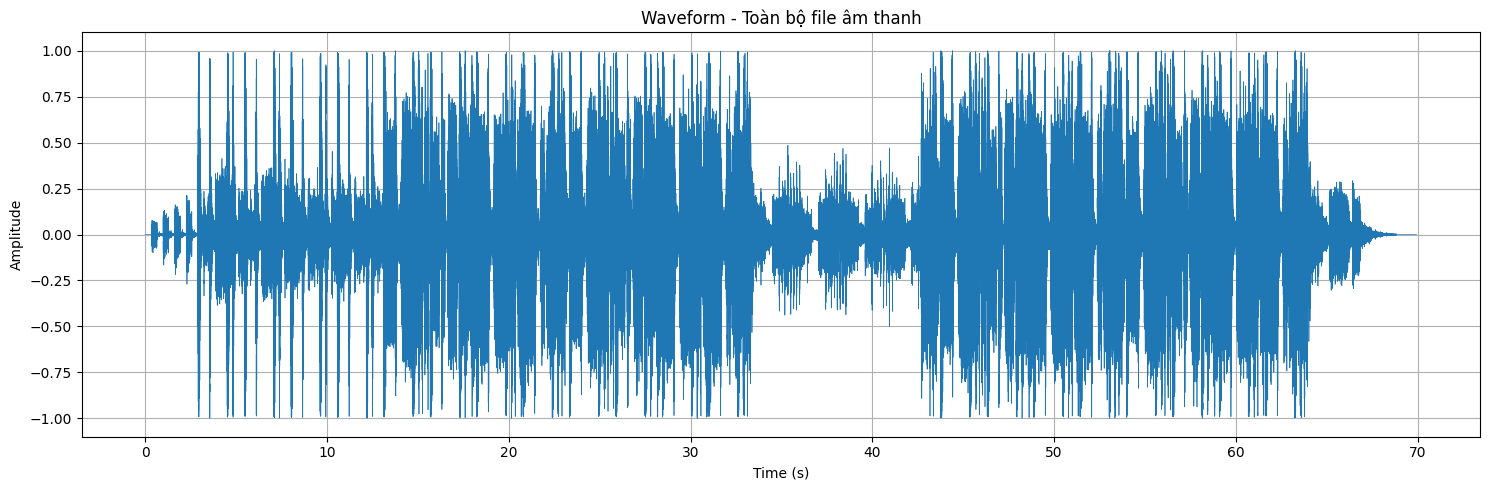

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(
    time,
    x,
    linewidth=0.5
)

plt.title("Waveform - Toàn bộ file âm thanh")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_waveform_full.png",
    dpi=200
)

plt.show()

PHÂN TÍCH CÁC ĐOẠN NGẮN

Đoạn 1
Time   : 0.000 - 0.500 s
Peak   : 0.099121
RMS    : 0.016178
Energy : 5.771409


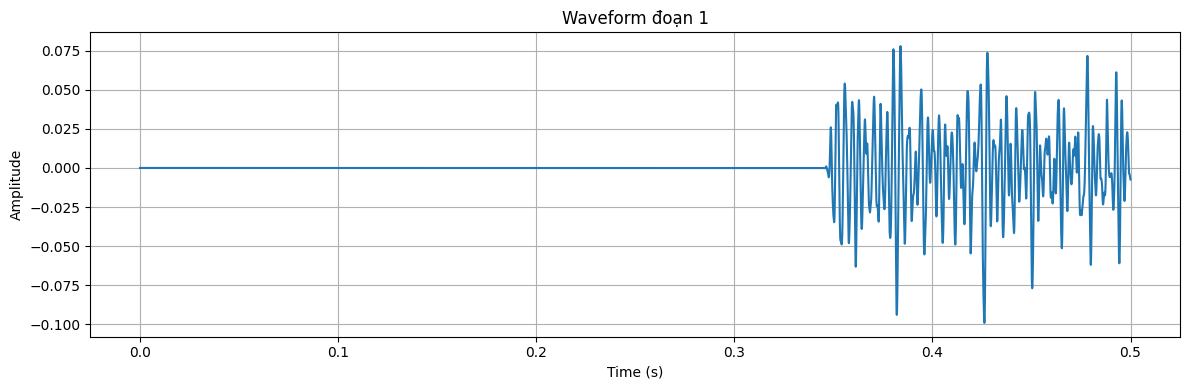


Đoạn 2
Time   : 34.965 - 35.465 s
Peak   : 0.485870
RMS    : 0.094432
Energy : 196.629734


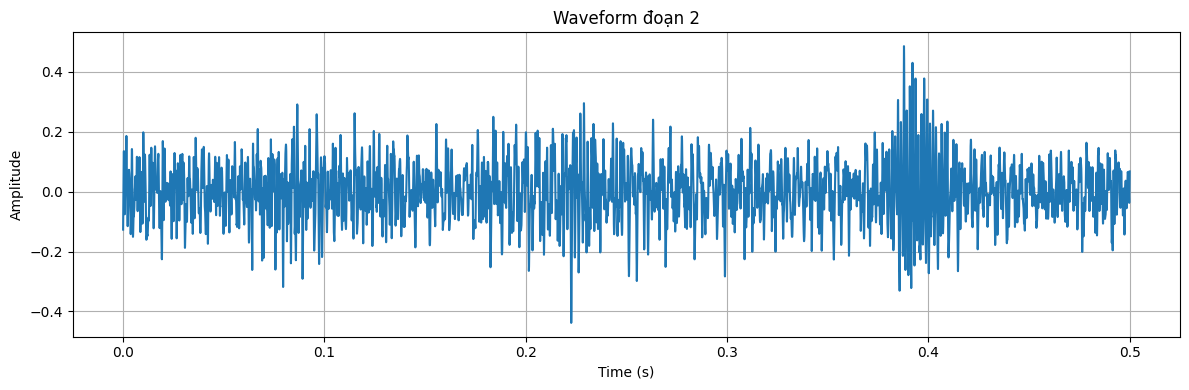

In [9]:
print("=" * 70)
print("PHÂN TÍCH CÁC ĐOẠN NGẮN")
print("=" * 70)

segment_duration = 0.5

# Đoạn đầu và đoạn giữa
segment_starts = [
    0,
    duration / 2
]

for i, start_time in enumerate(segment_starts, start=1):

    start_sample = int(start_time * Fs)

    end_sample = start_sample + int(
        segment_duration * Fs
    )

    end_sample = min(end_sample, N)

    segment = x[start_sample:end_sample]

    segment_time = np.arange(len(segment)) / Fs

    segment_peak = np.max(np.abs(segment))

    segment_rms = np.sqrt(
        np.mean(segment ** 2)
    )

    segment_energy = np.sum(
        segment ** 2
    )

    print(f"\nĐoạn {i}")
    print(
        f"Time   : "
        f"{start_sample/Fs:.3f} - "
        f"{end_sample/Fs:.3f} s"
    )

    print(f"Peak   : {segment_peak:.6f}")
    print(f"RMS    : {segment_rms:.6f}")
    print(f"Energy : {segment_energy:.6f}")

    plt.figure(figsize=(12, 4))

    plt.plot(
        segment_time,
        segment
    )

    plt.title(
        f"Waveform đoạn {i}"
    )

    plt.xlabel(
        "Time (s)"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"02_waveform_segment_{i}.png",
        dpi=200
    )

    plt.show()

In [10]:
print("=" * 70)
print("CHUẨN BỊ TÍN HIỆU CHO FFT")
print("=" * 70)

# Vị trí bắt đầu
fft_start_time = duration / 2

fft_start = int(
    fft_start_time * Fs
)

# Lấy 1 giây
fft_length = min(
    int(Fs),
    N - fft_start
)

fft_segment = x[
    fft_start:
    fft_start + fft_length
]

print(f"FFT bắt đầu tại : {fft_start_time:.2f} s")
print(f"Số mẫu           : {len(fft_segment)}")
print(f"Thời lượng       : {len(fft_segment)/Fs:.3f} s")

CHUẨN BỊ TÍN HIỆU CHO FFT
FFT bắt đầu tại : 34.96 s
Số mẫu           : 44100
Thời lượng       : 1.000 s


In [11]:
print("=" * 70)
print("FFT")
print("=" * 70)

# Hamming Window
window = np.hamming(
    len(fft_segment)
)

windowed_signal = (
    fft_segment * window
)

# NFFT
NFFT = 4096

# FFT
X = np.fft.rfft(
    windowed_signal,
    n=NFFT
)

# Trục tần số
freq = np.fft.rfftfreq(
    NFFT,
    d=1/Fs
)

# Magnitude
magnitude = np.abs(X)

# dB
magnitude_db = (
    20 *
    np.log10(
        magnitude /
        (np.max(magnitude) + 1e-12)
        + 1e-12
    )
)

# Frequency resolution
frequency_resolution = Fs / NFFT

print(f"NFFT              : {NFFT}")
print(f"Frequency spacing : {frequency_resolution:.3f} Hz")

FFT
NFFT              : 4096
Frequency spacing : 10.767 Hz


In [12]:
peaks, properties = signal.find_peaks(
    magnitude,
    distance=10,
    prominence=np.max(magnitude) * 0.01
)

if len(peaks) > 0:

    sorted_peaks = peaks[
        np.argsort(
            magnitude[peaks]
        )[::-1]
    ]

    print("10 đỉnh phổ nổi bật:\n")

    for idx in sorted_peaks[:10]:

        print(
            f"Frequency = "
            f"{freq[idx]:9.2f} Hz"
            f"   Magnitude = "
            f"{magnitude_db[idx]:7.2f} dB"
        )

10 đỉnh phổ nổi bật:

Frequency =   1044.36 Hz   Magnitude =    0.00 dB
Frequency =    312.23 Hz   Magnitude =   -0.47 dB
Frequency =    506.03 Hz   Magnitude =   -2.56 dB
Frequency =   1227.39 Hz   Magnitude =   -3.64 dB
Frequency =   1561.16 Hz   Magnitude =   -6.07 dB
Frequency =    775.20 Hz   Magnitude =   -6.45 dB
Frequency =    150.73 Hz   Magnitude =   -7.78 dB
Frequency =    915.16 Hz   Magnitude =   -7.95 dB
Frequency =    613.70 Hz   Magnitude =   -8.61 dB
Frequency =   1388.89 Hz   Magnitude =  -11.58 dB


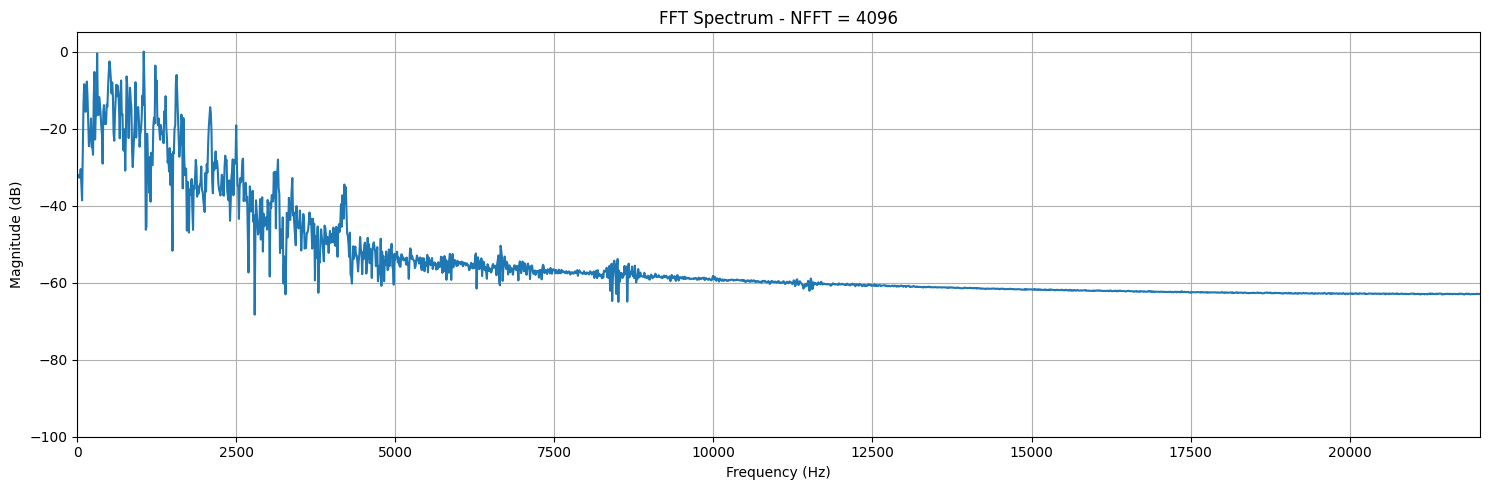

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    freq,
    magnitude_db
)

plt.title(
    "FFT Spectrum - NFFT = 4096"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Magnitude (dB)"
)

plt.xlim(
    0,
    Fs / 2
)

plt.ylim(
    -100,
    5
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "03_fft_spectrum.png",
    dpi=200
)

plt.show()

SO SÁNH NFFT
NFFT = 2048 -> Δf = 21.533 Hz
NFFT = 4096 -> Δf = 10.767 Hz
NFFT = 8192 -> Δf = 5.383 Hz


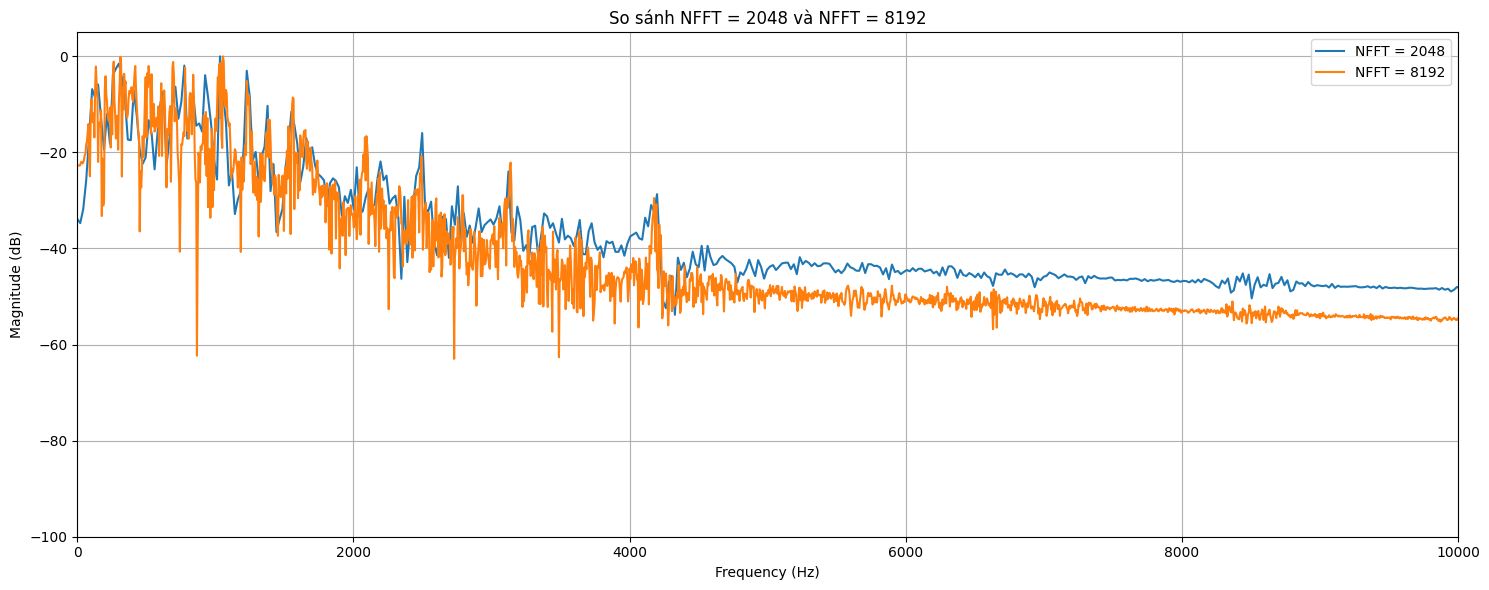

In [14]:
print("=" * 70)
print("SO SÁNH NFFT")
print("=" * 70)

print(
    f"NFFT = 2048 -> "
    f"Δf = {Fs/2048:.3f} Hz"
)

print(
    f"NFFT = 4096 -> "
    f"Δf = {Fs/4096:.3f} Hz"
)

print(
    f"NFFT = 8192 -> "
    f"Δf = {Fs/8192:.3f} Hz"
)

plt.figure(figsize=(15, 6))

for nfft in [2048, 8192]:

    spectrum = np.fft.rfft(
        windowed_signal,
        n=nfft
    )

    f = np.fft.rfftfreq(
        nfft,
        d=1/Fs
    )

    mag = np.abs(spectrum)

    mag_db = (
        20 *
        np.log10(
            mag /
            (np.max(mag) + 1e-12)
            + 1e-12
        )
    )

    plt.plot(
        f,
        mag_db,
        label=f"NFFT = {nfft}"
    )

plt.title(
    "So sánh NFFT = 2048 và NFFT = 8192"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.xlim(0, 10000)
plt.ylim(-100, 5)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "04_nfft_comparison.png",
    dpi=200
)

plt.show()

In [15]:
print("=" * 70)
print("STFT / SPECTROGRAM")
print("=" * 70)

# Frame = 25 ms
frame_ms = 25

# Hop = 10 ms
hop_ms = 10

nperseg = int(
    Fs * frame_ms / 1000
)

hop_samples = int(
    Fs * hop_ms / 1000
)

noverlap = (
    nperseg -
    hop_samples
)

print(f"Frame length : {frame_ms} ms")
print(f"Frame samples: {nperseg}")
print(f"Hop size     : {hop_ms} ms")
print(f"Hop samples  : {hop_samples}")

f_stft, t_stft, Zxx = signal.stft(
    x,
    fs=Fs,
    window="hamming",
    nperseg=nperseg,
    noverlap=noverlap,
    boundary=None
)

S_db = (
    20 *
    np.log10(
        np.abs(Zxx) + 1e-10
    )
)

STFT / SPECTROGRAM
Frame length : 25 ms
Frame samples: 1102
Hop size     : 10 ms
Hop samples  : 441


SO SÁNH ĐỘ DÀI FRAME STFT


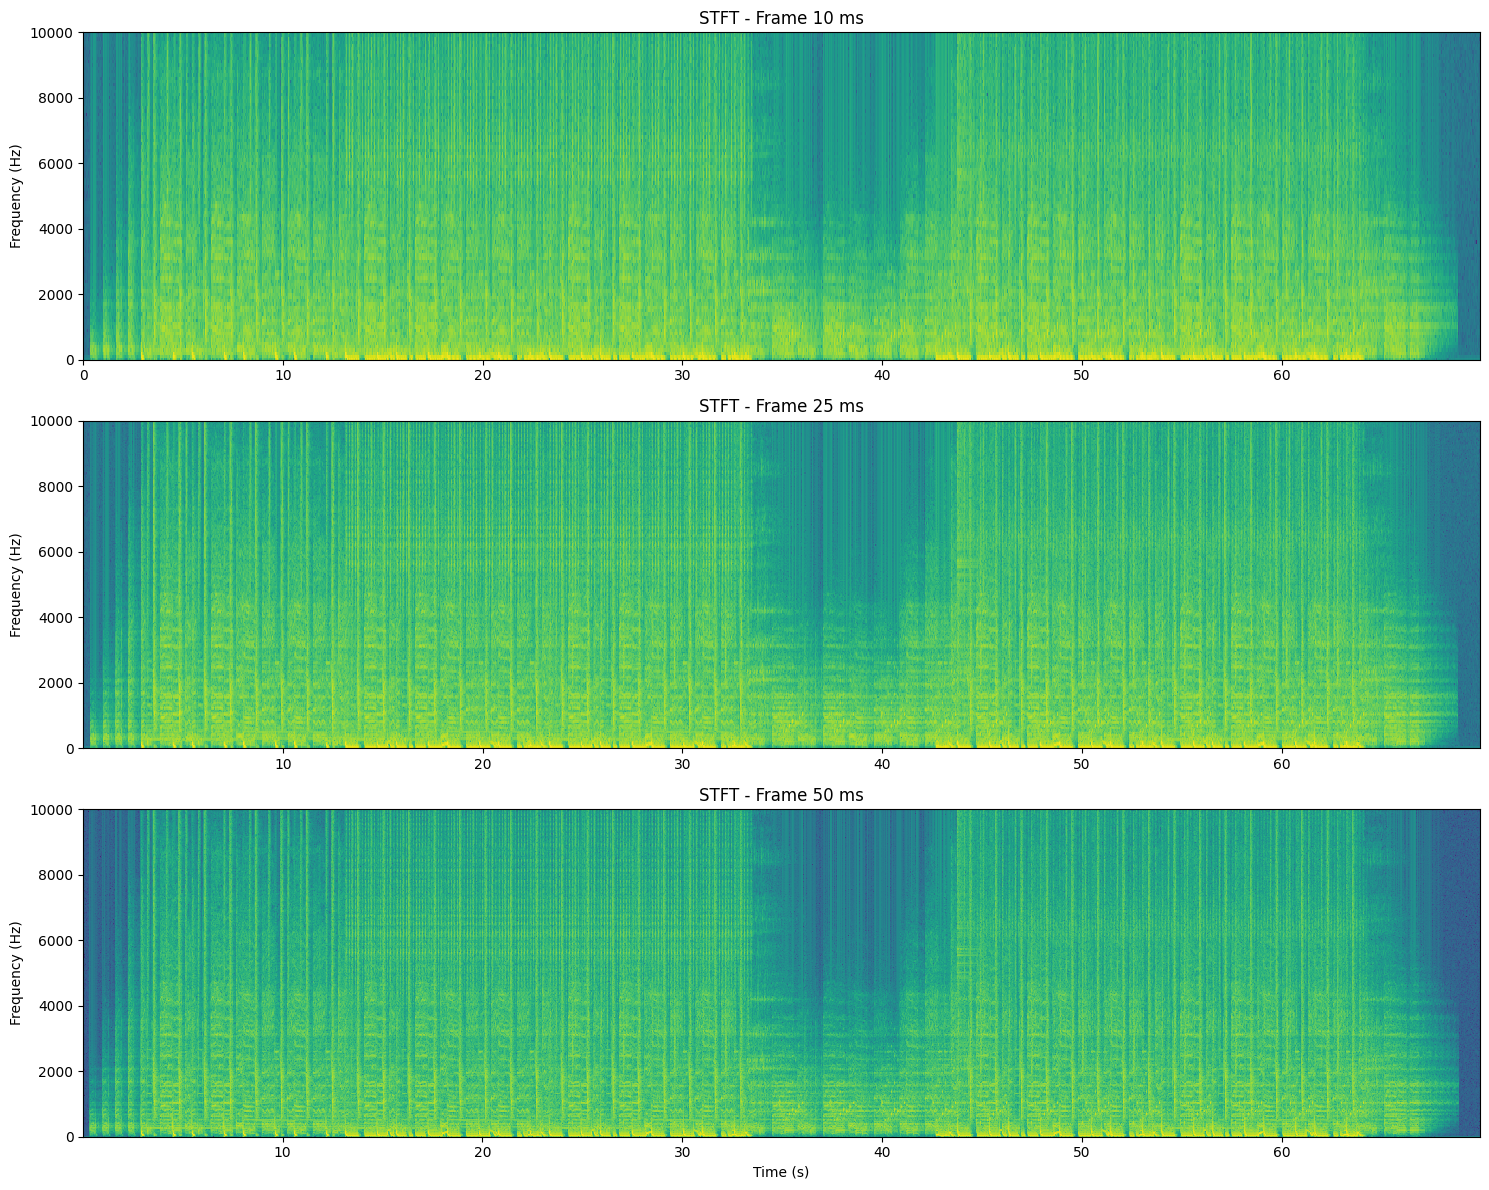

In [16]:
print("=" * 70)
print("SO SÁNH ĐỘ DÀI FRAME STFT")
print("=" * 70)

frame_sizes = [10, 25, 50]

plt.figure(figsize=(15, 12))

for i, frame_ms_test in enumerate(
    frame_sizes,
    start=1
):

    nperseg_test = int(
        Fs *
        frame_ms_test /
        1000
    )

    hop_test = int(
        Fs *
        10 /
        1000
    )

    noverlap_test = (
        nperseg_test -
        hop_test
    )

    f_test, t_test, Z_test = signal.stft(
        x,
        fs=Fs,
        window="hamming",
        nperseg=nperseg_test,
        noverlap=noverlap_test,
        boundary=None
    )

    S_test = (
        20 *
        np.log10(
            np.abs(Z_test) +
            1e-10
        )
    )

    plt.subplot(
        3,
        1,
        i
    )

    plt.pcolormesh(
        t_test,
        f_test,
        S_test,
        shading="auto"
    )

    plt.title(
        f"STFT - Frame {frame_ms_test} ms"
    )

    plt.ylabel(
        "Frequency (Hz)"
    )

    plt.ylim(
        0,
        10000
    )

plt.xlabel("Time (s)")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "06_frame_comparison.png",
    dpi=200
)

plt.show()

SO SÁNH WINDOW


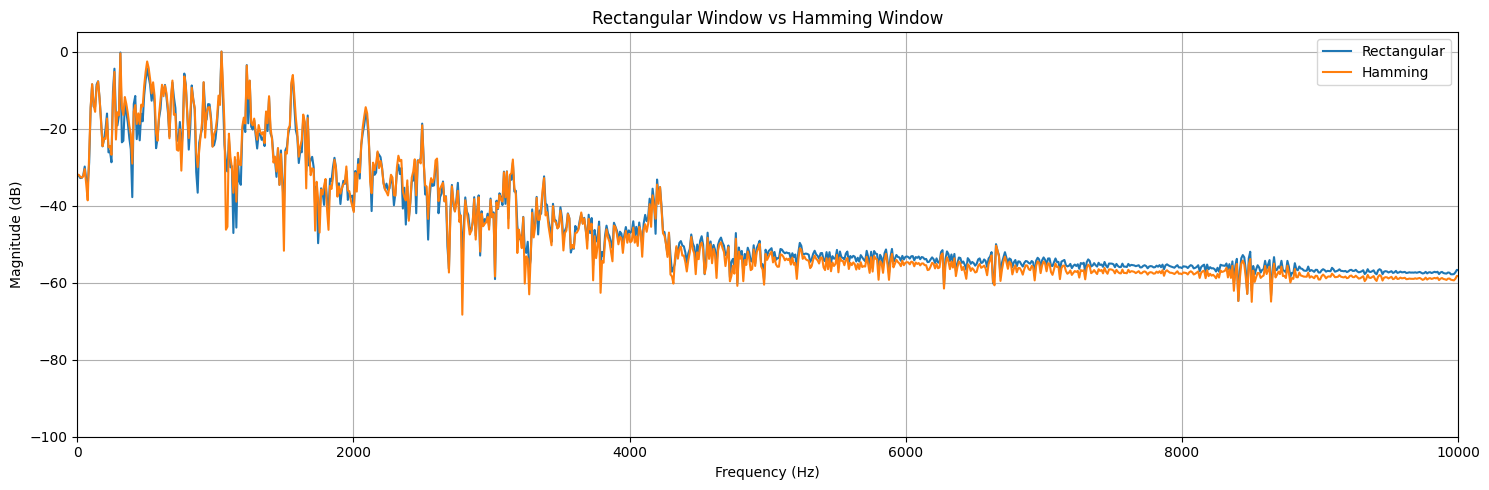

In [18]:
print("=" * 70)
print("SO SÁNH WINDOW")
print("=" * 70)

# Rectangular Window
rectangular_signal = fft_segment

# Hamming Window
hamming_signal = (
    fft_segment *
    np.hamming(
        len(fft_segment)
    )
)

NFFT_window = 4096

X_rect = np.fft.rfft(
    rectangular_signal,
    n=NFFT_window
)

X_hamming = np.fft.rfft(
    hamming_signal,
    n=NFFT_window
)

f_window = np.fft.rfftfreq(
    NFFT_window,
    d=1/Fs
)

rect_db = (
    20 *
    np.log10(
        np.abs(X_rect) /
        (np.max(np.abs(X_rect)) + 1e-12)
        + 1e-12
    )
)

hamming_db = (
    20 *
    np.log10(
        np.abs(X_hamming) /
        (np.max(np.abs(X_hamming)) + 1e-12)
        + 1e-12
    )
)

plt.figure(figsize=(15, 5))

plt.plot(
    f_window,
    rect_db,
    label="Rectangular"
)

plt.plot(
    f_window,
    hamming_db,
    label="Hamming"
)

plt.title(
    "Rectangular Window vs Hamming Window"
)

plt.xlabel(
    "Frequency (Hz)"
)

plt.ylabel(
    "Magnitude (dB)"
)

plt.xlim(
    0,
    10000
)

plt.ylim(
    -100,
    5
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "07_window_comparison.png",
    dpi=200
)

plt.show()

In [19]:
print("=" * 70)
print("TỔNG KẾT PHÂN TÍCH")
print("=" * 70)

print(f"""
File gốc              : {INPUT_FILE.name}

File WAV              : {wav_file}

Sampling rate         : {Fs} Hz
Channels              : Mono
Bit depth             : 16 bit
Duration              : {duration:.2f} s
Number of samples     : {N:,}

Peak                  : {peak:.6f}
RMS                   : {rms:.6f}
Energy                : {energy:.6f}
Zero Crossing Rate    : {zcr:.6f}
Clipping              : {clipping_percentage:.6f}%

FFT:
    NFFT              : {NFFT}
    Frequency spacing : {frequency_resolution:.3f} Hz

STFT:
    Frame             : {frame_ms} ms
    Hop               : {hop_ms} ms

Các biểu đồ được lưu tại:
    {FIGURE_DIR.absolute()}
""")

TỔNG KẾT PHÂN TÍCH

File gốc              : prettyjohn1-beat-523170.mp3

File WAV              : lab1_results\input_mono_44k1_16bit.wav

Sampling rate         : 44100 Hz
Channels              : Mono
Bit depth             : 16 bit
Duration              : 69.93 s
Number of samples     : 3,083,904

Peak                  : 1.000000
RMS                   : 0.274013
Energy                : 231549.375334
Zero Crossing Rate    : 0.039359
Clipping              : 0.001232%

FFT:
    NFFT              : 4096
    Frequency spacing : 10.767 Hz

STFT:
    Frame             : 25 ms
    Hop               : 10 ms

Các biểu đồ được lưu tại:
    c:\XLAT&TN\Lab1\lab1_results\figures

